In [1]:
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt
import geometric_phase_analysis_3D as gpa3D
from tqdm import tqdm
from scipy.fftpack import fftn, ifftn, fftshift, ifftshift, fft2, ifft2


100%|██████████| 157414/157414 [00:25<00:00, 6236.99it/s]


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

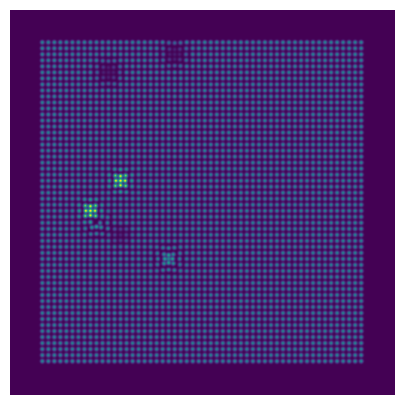

In [2]:
def gauss3D(xx, yy, zz, A, B, xc, yc, zc, sx, sy, sz):
    G = A*np.exp( - (((xx-xc)**2)/(2*sx**2) + ((yy-yc)**2)/(2*sy**2) + ((zz-zc)**2)/(2*sz**2)))+ B
    return G

N = 512; im_view_plane = N//2; x = np.linspace(0,N-1, N); [xx,yy,zz] = np.meshgrid(x,x,x); numAtoms = N//8; r = 2
num_sites =  numAtoms; num_vacancies =50; strain_range = 3; A = 0.6
lat_vec1 = np.array([8, 0, 0]); lat_vec2 = np.array([0, 8, 0]); lat_vec3 = np.array([0, 0, 8])

# Generate coordinates
bbuf = 12
xp = np.arange((N/bbuf)//1, N-(N/bbuf)//1, lat_vec1[0]).astype('float'); yp = np.arange((N/bbuf)//1, N-(N/bbuf)//1, lat_vec2[1]).astype('float'); zp = np.arange((N/bbuf)//1, N-(N/bbuf)//1, lat_vec3[2]).astype('float')
xx_, yy_, zz_ = np.meshgrid(xp, yp, zp, indexing='ij')

xx_f = xx_.flatten(); yy_f = yy_.flatten(); zz_f = zz_.flatten()

coords = np.column_stack((xx_f, yy_f, zz_f))
num_atoms = coords.shape[0]

# Generate vacancies
vacancy_ind = np.random.randint(num_atoms - 20, size=num_vacancies) + 20
vacancy_coords = coords[vacancy_ind]
coords = np.delete(coords, vacancy_ind, axis=0)

# Initialize strained coordinates and indices
strained_coords = np.empty((0, 3))
strained_ind = np.empty(0, dtype=int)

# Calculate strained coordinates
for i in range(num_vacancies):
    vac = vacancy_coords[i]
    dist = vac - coords
    total_dist = np.linalg.norm(dist, axis=1)

    # Find affected atoms
    vec_lim = min(min(lat_vec1[0], lat_vec2[1]), lat_vec3[2])
    nearest_neighbor_ind = np.where(total_dist < vec_lim * strain_range)[0]

    # Create Gaussian matrix
    x_lim = np.linspace(np.min(coords[nearest_neighbor_ind, 0]), np.max(coords[nearest_neighbor_ind, 0]), num=100)
    y_lim = np.linspace(np.min(coords[nearest_neighbor_ind, 1]), np.max(coords[nearest_neighbor_ind, 1]), num=100)
    z_lim = np.linspace(np.min(coords[nearest_neighbor_ind, 2]), np.max(coords[nearest_neighbor_ind, 2]), num=100)

    x_nn, y_nn, z_nn = np.meshgrid(x_lim, y_lim, z_lim, indexing='ij')
    gauss_mat = A * np.exp(-((x_nn - vac[0])**2 / (2 * lat_vec1[0]**2) + 
                                (y_nn - vac[1])**2 / (2 * lat_vec2[1]**2) + 
                                (z_nn - vac[2])**2 / (2 * lat_vec3[2]**2)))

    # Update strained coordinates and indices
    for nn_ind in nearest_neighbor_ind:
        x_change_ind = np.argmin(np.abs(x_lim-coords[nn_ind, 0]))
        y_change_ind = np.argmin(np.abs(y_lim-coords[nn_ind, 1]))
        z_change_ind = np.argmin(np.abs(z_lim-coords[nn_ind, 2]))

        scale_val = gauss_mat[y_change_ind, x_change_ind, z_change_ind]
        new_coords = coords[nn_ind] + dist[nn_ind] * scale_val

        if nn_ind not in strained_ind:
            strained_coords = np.vstack((strained_coords, new_coords))
            strained_ind = np.append(strained_ind, nn_ind)

coords[strained_ind] = strained_coords
px, py, pz = coords[:, 0], coords[:, 1], coords[:, 2]


# px = np.reshape(px, [num_sites, num_sites, num_sites])
# py = np.reshape(py, [num_sites, num_sites, num_sites])
# pz = np.reshape(pz, [num_sites, num_sites, num_sites])

sg = 2

totalVolume = np.zeros(xx.shape)

N_2 = 21
init_arr = np.zeros([N_2,N_2,N_2])

xL = np.linspace(-N_2/2,N_2/2-1, N_2)
yL = np.linspace(-N_2/2,N_2/2-1, N_2)
zL = np.linspace(-N_2/2,N_2/2-1, N_2)

[xxL,yyL,zzL] = np.meshgrid(xL,yL,zL)

for i in tqdm(range(px.shape[0])):
    int_coordinate = np.array([px[i]//1, py[i]//1, pz[i]//1]) 
    dec_coordinate = np.array([px[i]%1, py[i]%1, pz[i]%1])
    rr = np.sqrt((xxL-dec_coordinate[1])**2 + (yyL-dec_coordinate[0])**2 + (zzL-dec_coordinate[2])**2 )
    init_arr = sp.erfc( (rr-r)/sg ) / 2 
    totalVolume[(int(int_coordinate[0])-N_2//2):(int(int_coordinate[0])+N_2//2+1),(int(int_coordinate[1])-N_2//2):(int(int_coordinate[1])+N_2//2+1), (int(int_coordinate[2])-N_2//2):(int(int_coordinate[2])+N_2//2+1)] =  totalVolume[(int(int_coordinate[0])-N_2//2):(int(int_coordinate[0])+N_2//2+1),(int(int_coordinate[1])-N_2//2):(int(int_coordinate[1])+N_2//2+1), (int(int_coordinate[2])-N_2//2):(int(int_coordinate[2])+N_2//2+1)] + init_arr

im = totalVolume
nx = N; ny = N; nz = N

plt.figure(figsize = (5,5))
plt.imshow(im[N//2,:,:], origin = 'upper'); plt.axis('off')

100%|██████████| 25/25 [00:35<00:00,  1.41s/it]


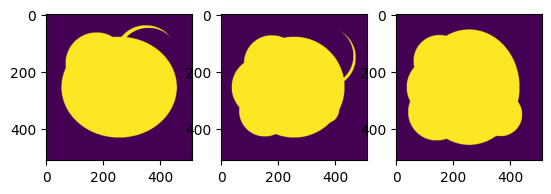

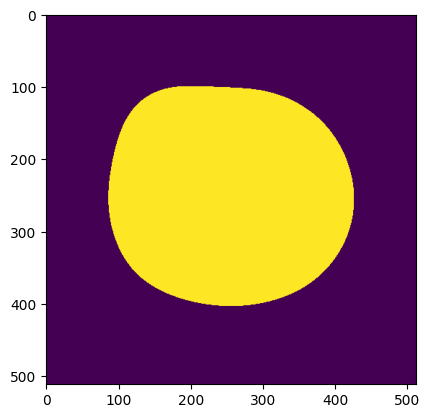

In [ ]:
do_nanoparticle_mask = True
def generate_large_scale_radial_mask(shape, center, noise_scale=0.5, num_perturbations=20):
    """
    Generate a radial mask with large-scale variations.

    Parameters:
    - shape: Shape of the output mask (tuple)
    - center: Coordinates of the center of the radial mask (tuple)
    - radius: Radius of the radial mask (int)
    - noise_scale: Scale of the noise for perturbations (float) (default: 0.5)
    - num_perturbations: Number of perturbations to apply (int) (default: 20)

    Returns:
    - 3D array representing the radial mask with large-scale variations
    """
    mask = np.zeros(shape)


    N = shape[0]
    quarter_point = np.ones(3)*N//4*noise_scale

    # Decide the radius for the nanoparticle
    rand_range = N//8
    rand_numbers = np.random.rand(3)
    radius_variation = rand_range*(rand_numbers-np.mean(rand_numbers))
    radius = quarter_point+radius_variation
    # Generate a grid of coordinates
    x = np.arange(shape[0]).astype('float')
    y = np.arange(shape[1]).astype('float')
    z = np.arange(shape[2]).astype('float')
    xx, yy, zz = np.meshgrid(x, y, z, indexing='ij')#.astype('float')
    center = np.array([N//2, N//2, N//2]) 

    # Compute distances from the center
    distances = np.sqrt(((xx - center[0])/radius[0])**2 + ((yy - center[1])/radius[1])**2 + ((zz - center[2])/radius[0])**2)


    # Create perturbations
    for _ in tqdm(range(num_perturbations)):
        perturbation_center = np.random.randint(0.1*N*noise_scale, 0.15*N*noise_scale, size=3)
        perturbation_center = perturbation_center*np.random.randint(-1,2,3)
        perturbation_radius = np.random.randint(0.1*N*noise_scale,0.15*N*noise_scale)  # Adjust the range as needed

        # Add perturbation to distances
        perturbation = np.sqrt((xx - center[0]-perturbation_center[0])**2 + (yy -  center[1]-perturbation_center[1])**2 + (zz -  center[2]-perturbation_center[2])**2)
        mask[perturbation <= perturbation_radius] = np.random.randint(0,2)

    # Set values inside the radius to 1
    mask[distances <= 1] = 1

    return mask

# Example usage:
# N = 256
shape = np.array([N, N, N])
center = np.array([N//2, N//2, N//2]) 

noise_scale = 1.5
num_perturbations = 25
large_scale_radial_mask = generate_large_scale_radial_mask(shape, center, noise_scale, num_perturbations)

# Now you have a radial mask with large-scale variations stored in the `large_scale_radial_mask` array
plt.figure()
plt.subplot(131)
plt.imshow(large_scale_radial_mask[:,:,center[2]], origin = 'upper')
plt.subplot(132)
plt.imshow(large_scale_radial_mask[:,center[1],:], origin = 'upper')
plt.subplot(133)
plt.imshow(large_scale_radial_mask[center[0],:,:], origin = 'upper')

# Fourier filter the mask
ft_mask_l = fftshift(fftn(large_scale_radial_mask))
A = 1; B = 0
sx = sy = sz = 2
gaussian = gauss3D(xx-N/2,yy-N/2,zz-N/2, A, B, 0, 0, 0, sx, sy, sz)

mask_blurred = np.abs(ifftn(ft_mask_l*gaussian))
mask_bin = np.zeros(mask_blurred.shape)
mask_bin[mask_blurred>0.7] = 1
mask_bin[mask_bin<1] = 0
plt.figure()
plt.imshow(mask_bin[:,:,im_view_plane], origin = 'upper')

if do_nanoparticle_mask == True:
    im = mask_bin*im


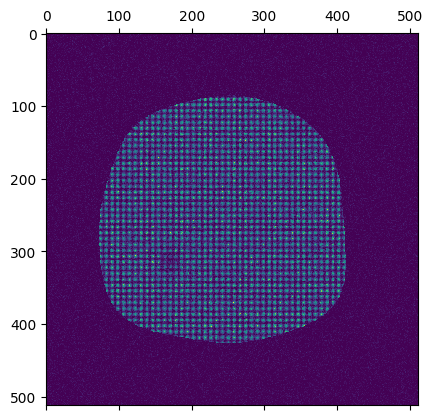

In [13]:
add_noise = True
noisy_im = np.random.poisson(im*100)
sigma = 2
noisy_im = noisy_im + np.random.normal(0, sigma, noisy_im.shape)
noisy_im = noisy_im - np.mean(noisy_im[:5,:5,:5])
noisy_im[noisy_im<0] = 0
plt.matshow(noisy_im[N//2])
if add_noise:
    im = noisy_im

In [14]:
gpa_object = gpa3D.geometric_phase_analysis_3D(im)

In [15]:
diffraction_peaks = gpa_object.locate_diffraction_spots(15)
peakA, peakB, peakC = gpa_object.locate_first_order_peaks(diffraction_peaks)
print(peakA)
print(peakB)
print(peakC)

[1.16415150e-10 4.11995812e-19 1.66121458e-16 2.62143706e+05
 2.62143706e+05 2.62142191e+05 2.62142191e+05 2.62144912e+05
 2.62144912e+05 2.62143298e+05 2.62143298e+05 2.62146429e+05
 2.62146429e+05]
[(319.99989496, 256.00043193, 255.99990278, 1.32353702e+08)]
[(255.99978458, 192.00010363, 255.99999229, 1.32480835e+08)]
[(256.00017097, 255.99992824, 320.00013694, 1.32488811e+08)]


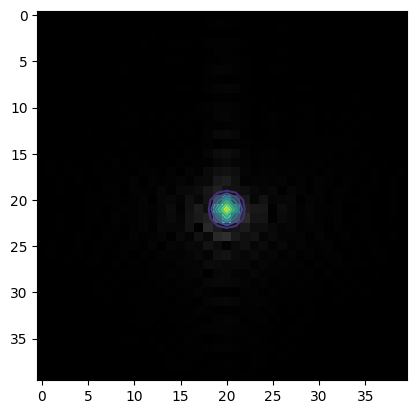

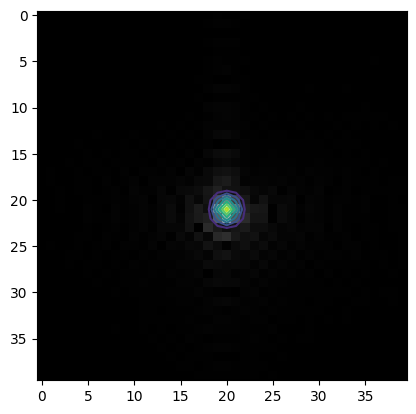

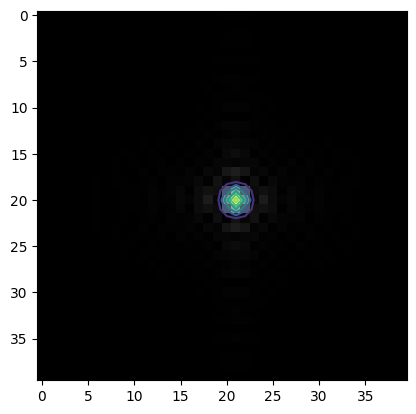

In [16]:
peakAPrecise = gpa_object.precise_peak_location(peakA)
peakBPrecise = gpa_object.precise_peak_location(peakB)
peakCPrecise = gpa_object.precise_peak_location(peakC)

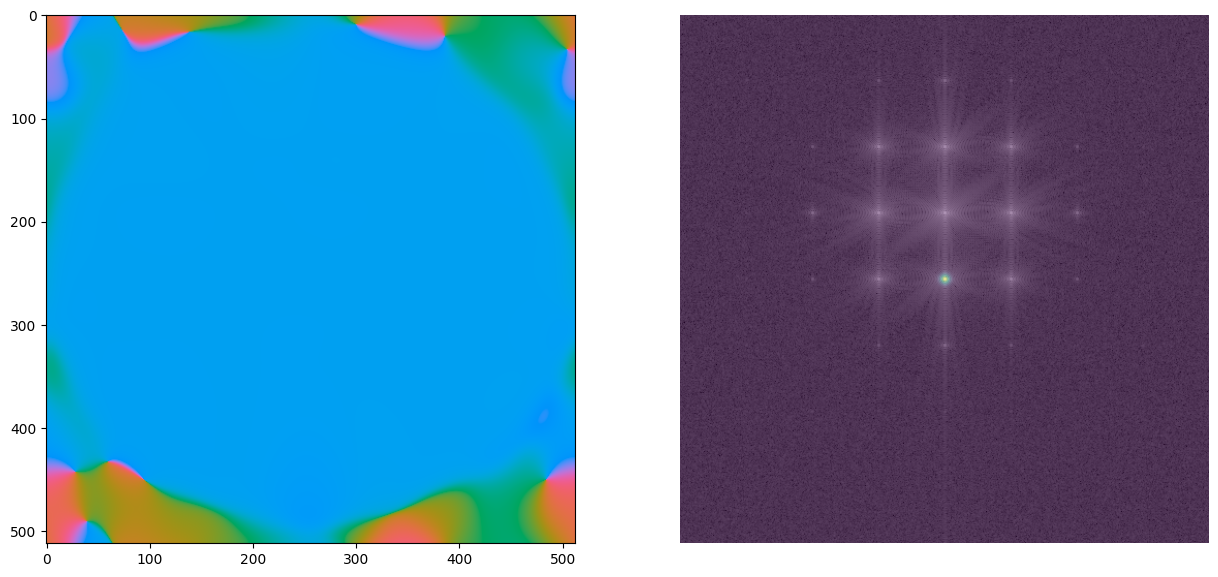

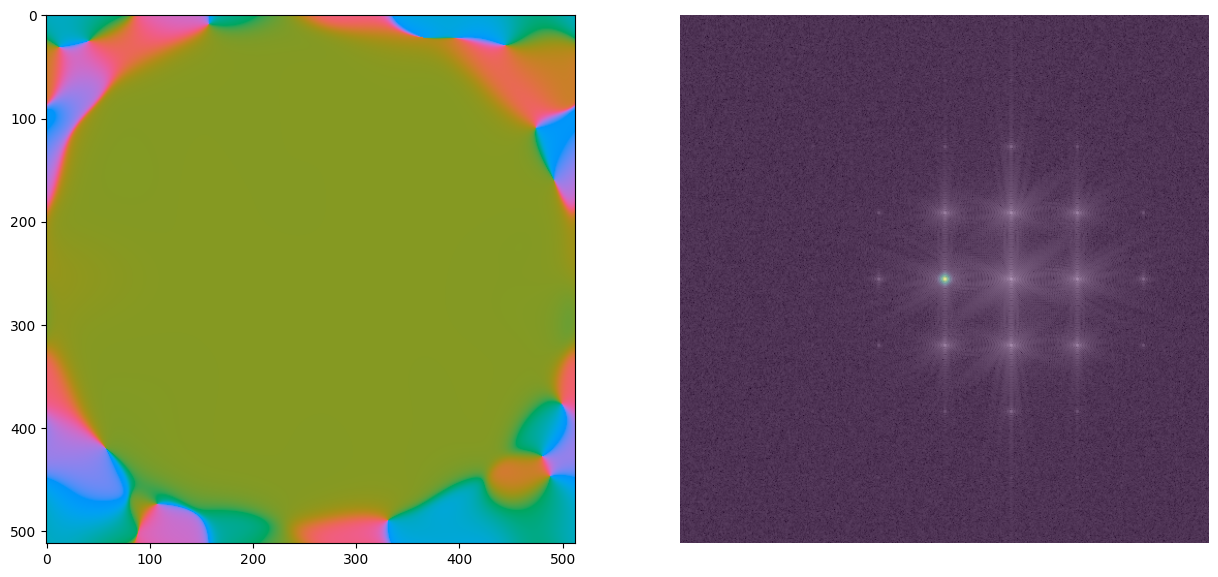

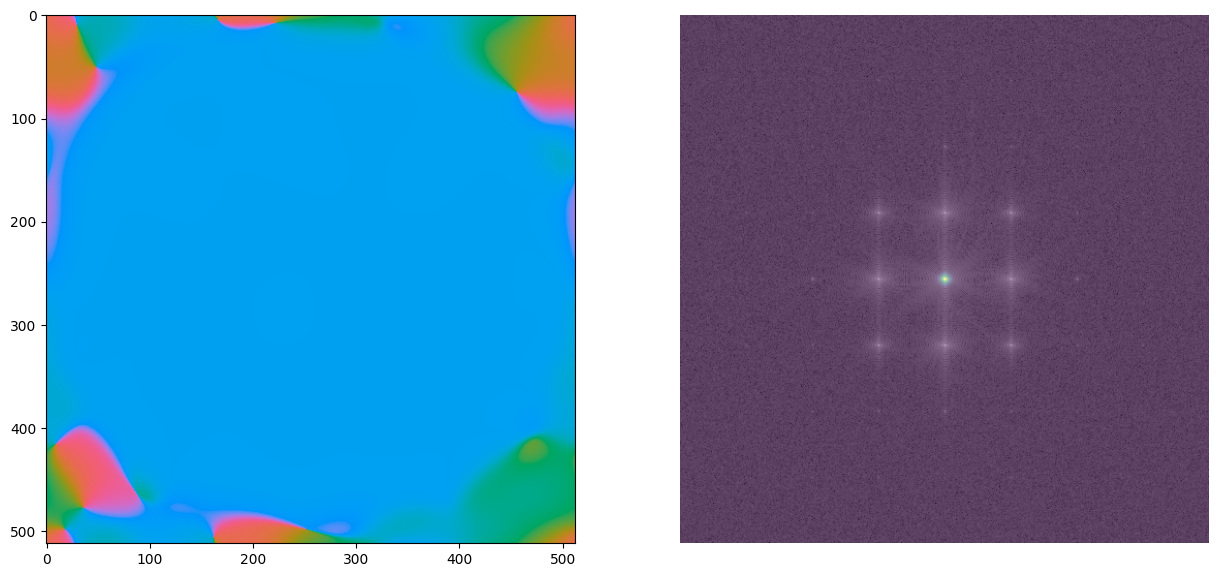

In [17]:
maskSize = 10
phaseA = gpa_object.calculate_phase_map(peakAPrecise,maskSize)
phaseB = gpa_object.calculate_phase_map(peakBPrecise,maskSize)
phaseC = gpa_object.calculate_phase_map(peakCPrecise,maskSize)

In [18]:
# e_mat = gpa_object.calculate_strain_map_phase(peakAPrecise, peakBPrecise, peakCPrecise, phaseA, phaseB, phaseC, showResult = True)

/home/wmill/COlab/Projects/20250709_quantEM/quantem/vquantem/lib/python3.12/site-packages/skimage/restoration/unwrap.py:103: ComplexWarning: Casting complex values to real discards the imaginary part
  image_not_masked = np.asarray(np.ma.getdata(image), dtype=np.float64, order='C')


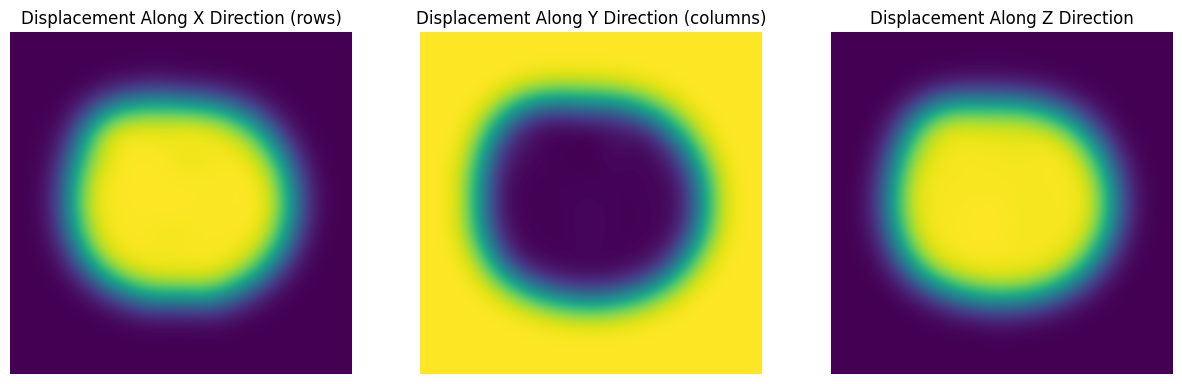

In [19]:
displacementA, displacementB, displacementC = gpa_object.calculate_displacement_map(peakAPrecise, peakBPrecise, peakCPrecise, phaseA, phaseB, phaseC, showResult = True)

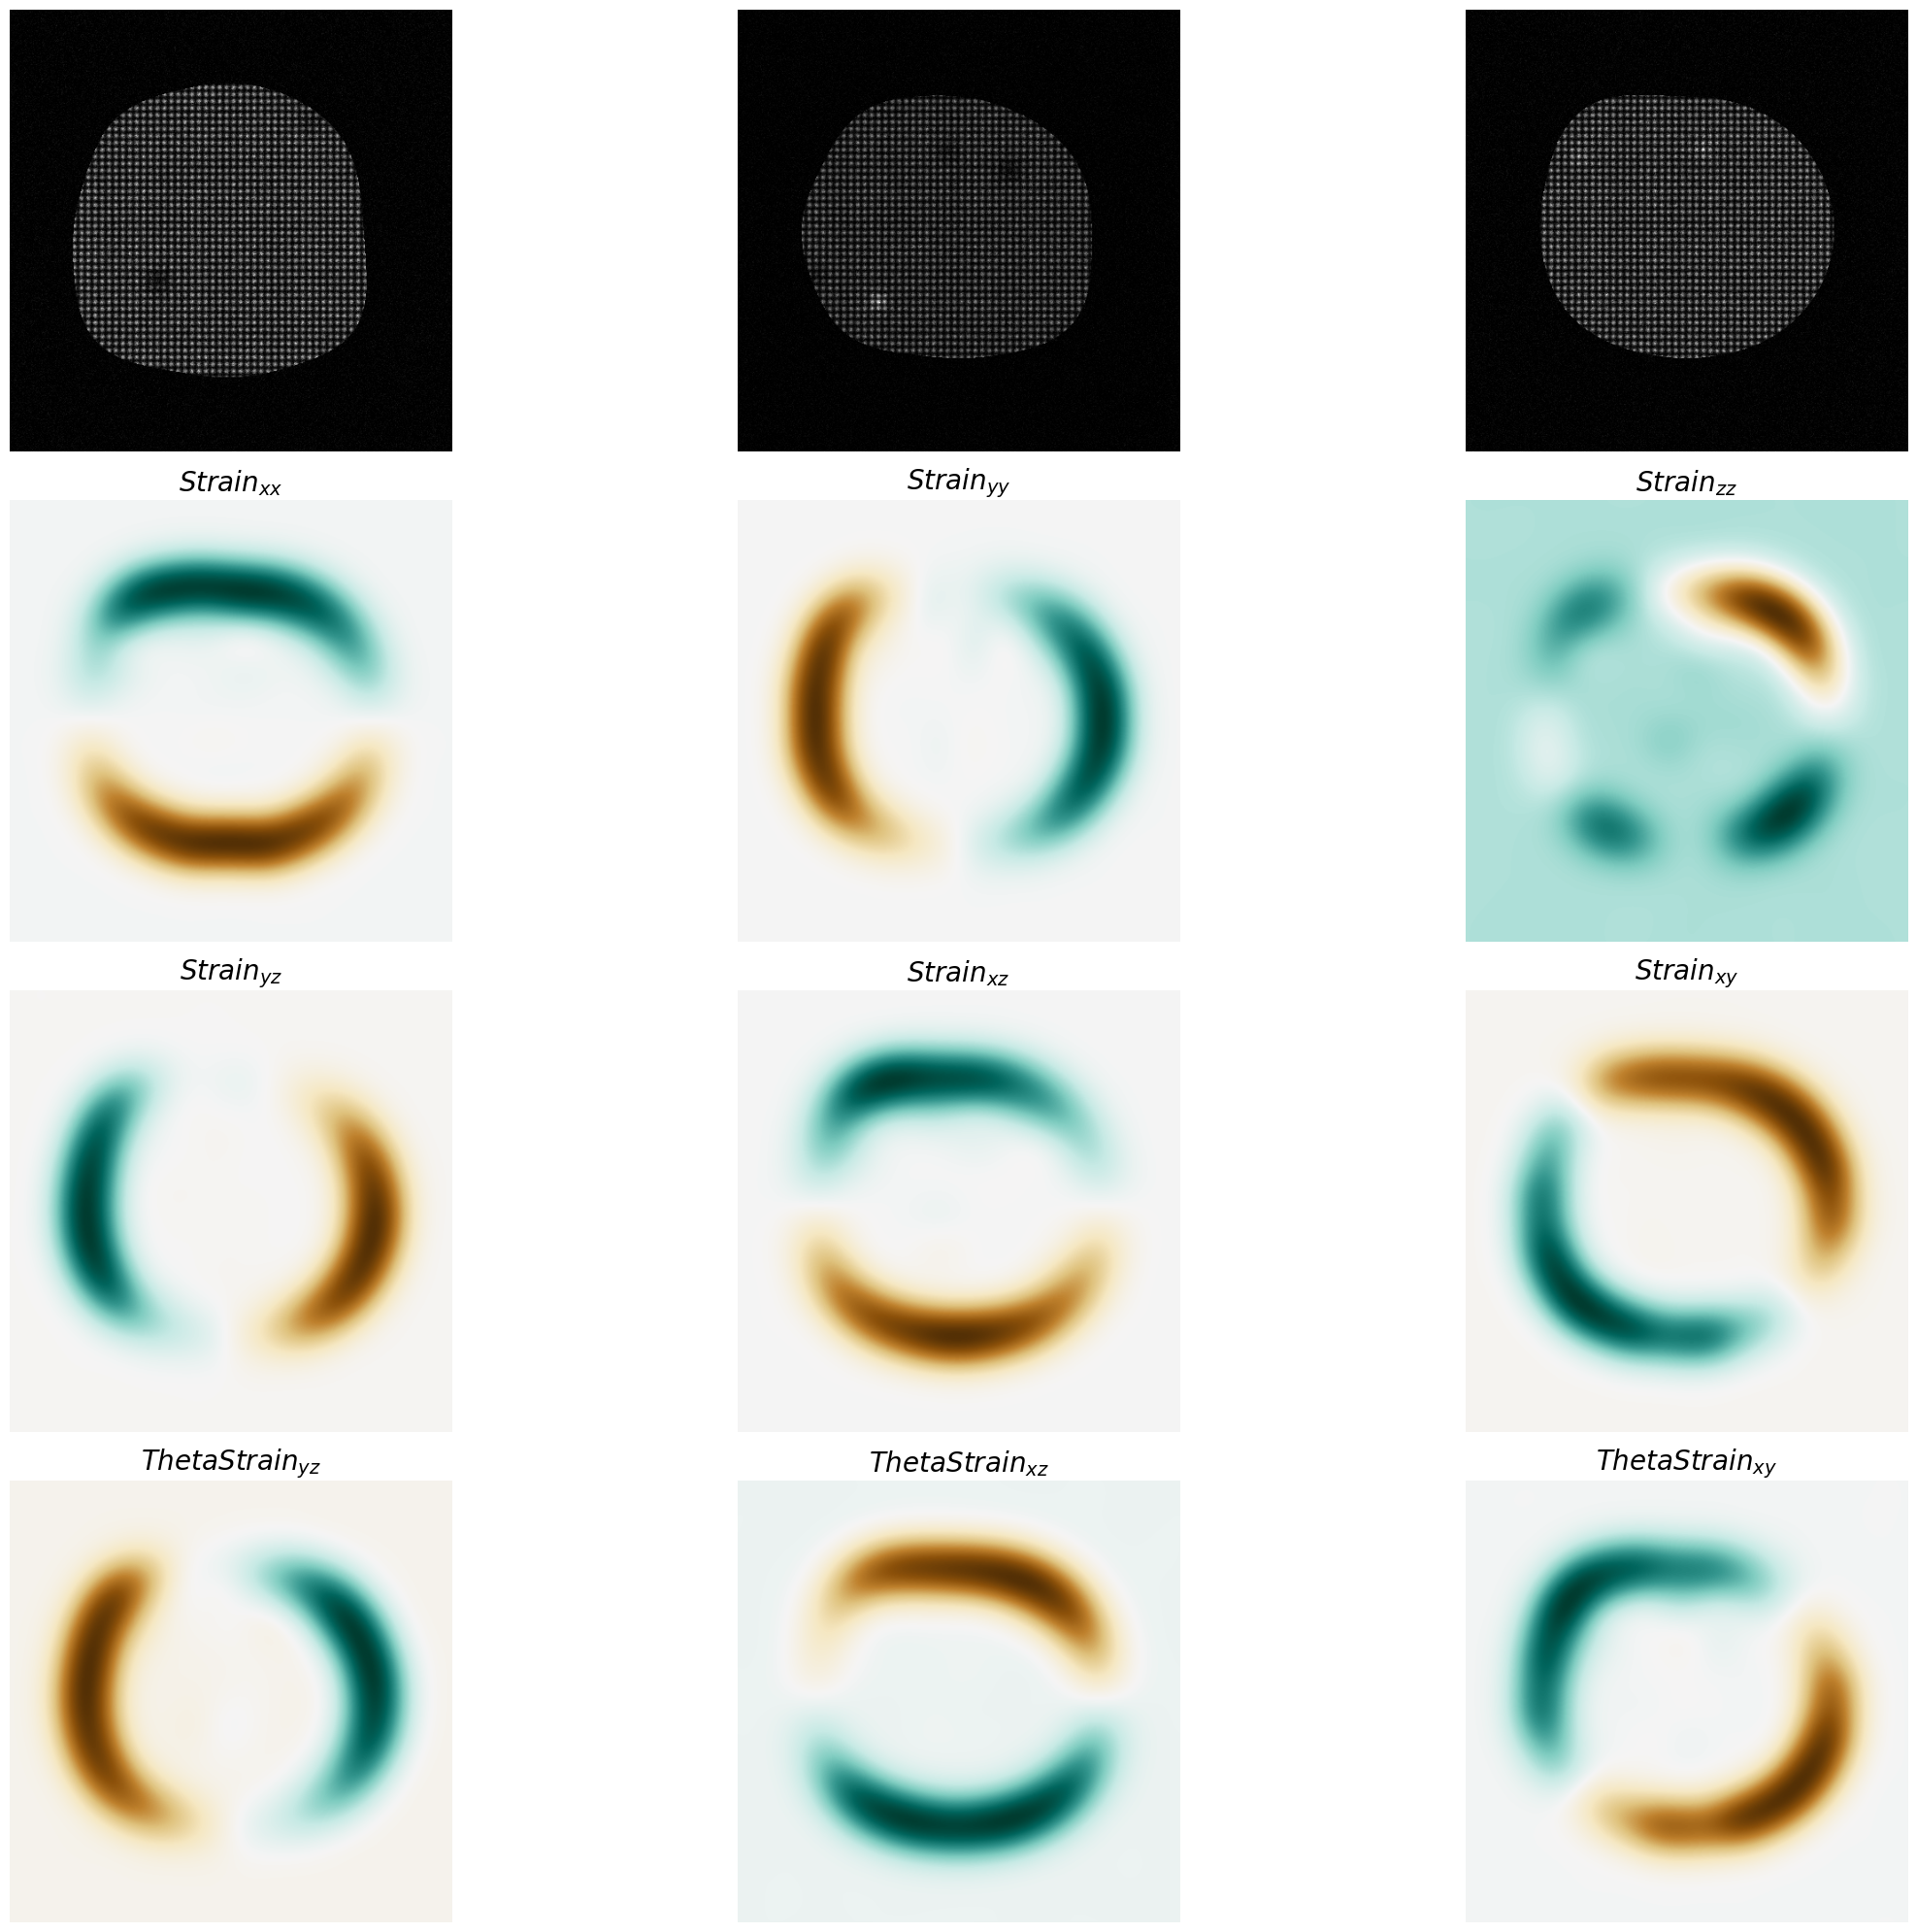

In [20]:
e_mat = gpa_object.calculate_strain_map(displacementA, displacementB, displacementC)

In [3]:
e_xx, e_yy, e_zz = gpa_object.get_axial_strain(e_mat)
e_th_xy, e_th_xz, e_th_yz, e_dg_xy, e_dg_xz, e_dg_yz = gpa_object.get_rot_and_diag_strain(e_mat)
nz = 512
(fig,axs) = plt.subplots(3,3, figsize = (20,20))
axs = axs.flatten()
ff_threshold = 1
axs[0].imshow(gpa_object.fourier_filter(e_xx, threshold = ff_threshold)[:,:, nz//2], cmap = 'BrBG', origin = 'upper'); axs[0].set_title('$Strain_{xx}$', fontsize = 20); axs[0].axis('off')
axs[1].imshow(gpa_object.fourier_filter(e_yy, threshold = ff_threshold)[:,:, nz//2], cmap = 'BrBG', origin = 'upper'); axs[1].set_title('$Strain_{yy}$', fontsize = 20); axs[1].axis('off')
axs[2].imshow(gpa_object.fourier_filter(e_zz, threshold = ff_threshold)[:,:, nz//2], cmap = 'BrBG', origin = 'upper'); axs[2].set_title('$Strain_{zz}$', fontsize = 20); axs[2].axis('off')
axs[3].imshow(gpa_object.fourier_filter(e_dg_yz, threshold = ff_threshold)[:,:, nz//2], cmap = 'BrBG', origin = 'upper'); axs[3].set_title('$Strain_{yz}$', fontsize = 20); axs[3].axis('off')
axs[4].imshow(gpa_object.fourier_filter(e_dg_xz, threshold = ff_threshold)[:,:, nz//2], cmap = 'BrBG', origin = 'upper'); axs[4].set_title('$Strain_{xz}$', fontsize = 20); axs[4].axis('off')
axs[5].imshow(gpa_object.fourier_filter(e_dg_xy, threshold = ff_threshold)[:,:, nz//2], cmap = 'BrBG', origin = 'upper'); axs[5].set_title('$Strain_{xy}$', fontsize = 20); axs[5].axis('off')
axs[6].imshow(gpa_object.fourier_filter(e_th_yz, threshold = ff_threshold)[:,:, nz//2], cmap = 'BrBG', origin = 'upper'); axs[6].set_title('$Theta Strain_{yz}$', fontsize = 20); axs[6].axis('off')
axs[7].imshow(gpa_object.fourier_filter(e_th_xz, threshold = ff_threshold)[:,:, nz//2], cmap = 'BrBG', origin = 'upper'); axs[7].set_title('$Theta Strain_{xz}$', fontsize = 20); axs[7].axis('off')
axs[8].imshow(gpa_object.fourier_filter(e_th_xy, threshold = ff_threshold)[:,:, nz//2], cmap = 'BrBG', origin = 'upper'); axs[8].set_title('$Theta Strain_{xy}$', fontsize = 20); axs[8].axis('off')
plt.tight_layout()

plt.figure()
plt.imshow(im[:,:, nz//2], cmap = 'gray', origin = 'upper')
plt.axis('off')

NameError: name 'gpa_object' is not defined

## Refine Phase Estimate

/home/wmill/COlab/Projects/20250709_quantEM/quantem/src/quantem/analysis/geometric_phase_analysis_3D.py:855: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate(A, (A[0]/self.nx, (1 - A[1]/self.ny)), textcoords='axes fraction', size=15,color='w')
/home/wmill/COlab/Projects/20250709_quantEM/quantem/src/quantem/analysis/geometric_phase_analysis_3D.py:856: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate(B, (B[0]/self.nx, (1 - B[1]/self.ny)), textcoords='axes fraction', size=15,color='w')
/home/wmill/COlab/Projects/20250709_quantEM/quantem/src/quantem/analysis/geometric_phase_analysis_3D.py:857: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate(C, (C[0]/self.nx, (1 - C[1]/self.ny)), textcoords='axes fraction', size=15,color='w')
/home/wmill/COlab/P

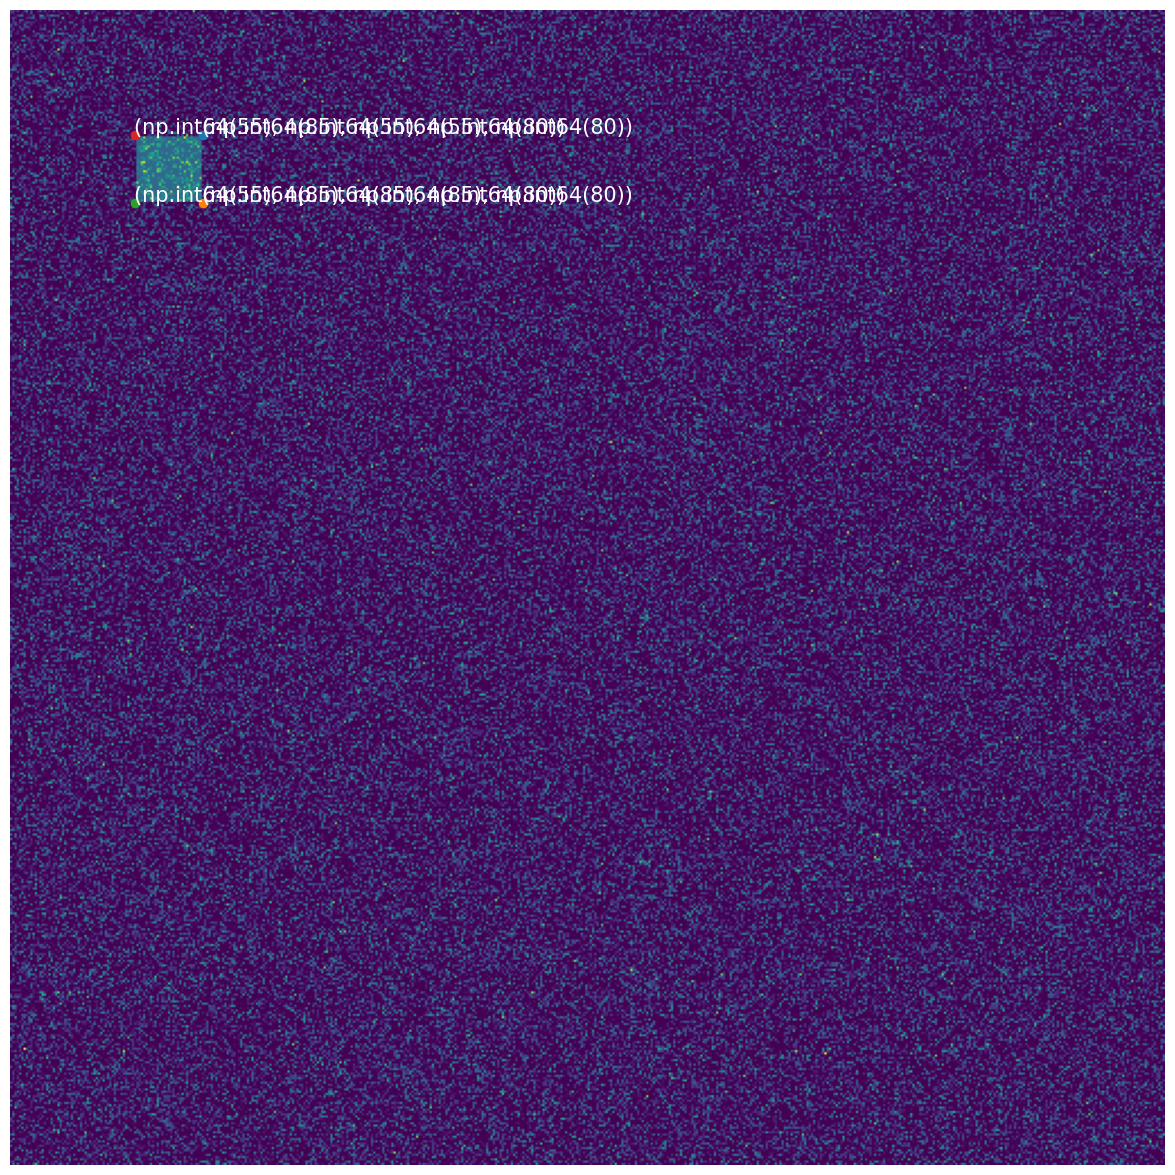

In [13]:
refMatrix = gpa_object.set_reference_matrix(np.array([70,70,65]), 15)

KeyboardInterrupt: 

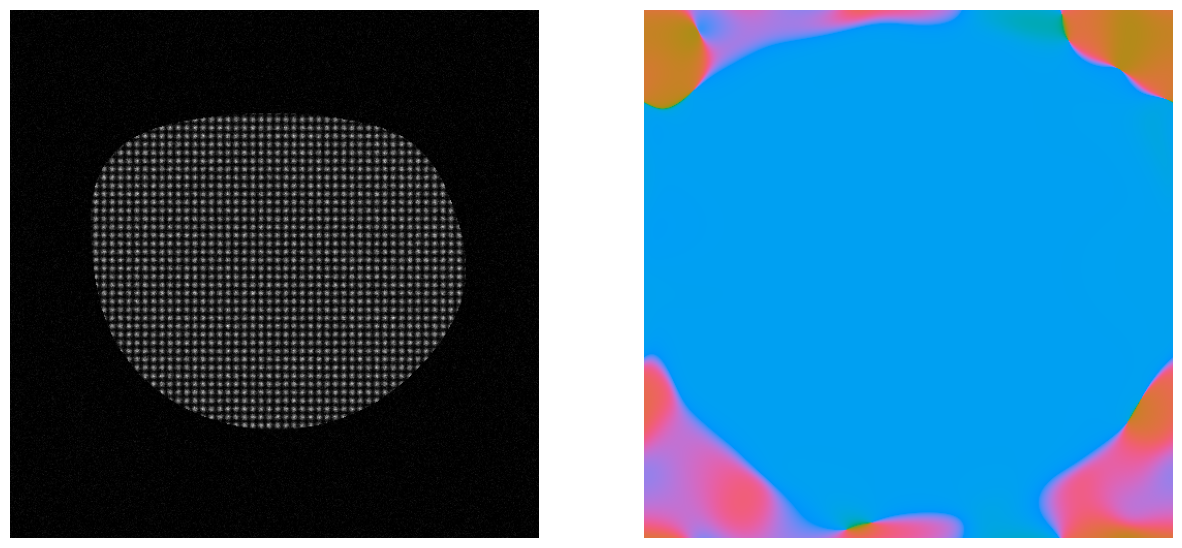

In [14]:
iterations = 25
useGaussMask = True
peakARefined, phaseARefined = gpa_object.refine_phase(phaseA, peakA, refMatrix, maskSize, iterations, useGaussMask)
peakBRefined, phaseBRefined = gpa_object.refine_phase(phaseB, peakB, refMatrix, maskSize, iterations, useGaussMask)
peakCRefined, phaseCRefined = gpa_object.refine_phase(phaseC, peakC, refMatrix, maskSize, iterations, useGaussMask)